# 🚢 Transformer Model for 6-DoF Ship Motion Prediction

This notebook trains a **Transformer-based neural network** to predict 6-Degree-of-Freedom (6-DoF) ship motions in irregular waves.

**Task**: Given 10 seconds of historical motion data (100 timesteps), predict the ship's motion for the next 5 seconds (50 timesteps).

**6-DoF Motions**:
- Surge (forward/backward)
- Sway (side-to-side)
- Heave (up/down)
- Roll (rotation about longitudinal axis)
- Pitch (rotation about lateral axis)
- Yaw (rotation about vertical axis)

---

## 1. Mount Google Drive
Run this cell first to mount your Google Drive for saving the trained model.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Create directory for saving models
import os
save_dir = '/content/drive/MyDrive/ShipMotionTransformer'
os.makedirs(save_dir, exist_ok=True)
print(f"✓ Model save directory: {save_dir}")

Mounted at /content/drive
✓ Model save directory: /content/drive/MyDrive/ShipMotionTransformer


## 2. Import Libraries

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy import interpolate
import math
import warnings
import pickle
import json
from datetime import datetime

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Using device: {device}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

✓ Using device: cuda
  GPU: Tesla T4


## 3. Configuration Parameters

In [7]:
class Config:
    """Configuration class for all hyperparameters and settings"""

    # Data parameters
    INPUT_WINDOW = 100      # 10 seconds at 10 Hz
    OUTPUT_WINDOW = 50      # 5 seconds at 10 Hz
    STRIDE = 10             # Sliding window stride
    SAMPLING_RATE = 10      # Hz

    # Motion columns (6-DoF) - these are the target outputs
    MOTION_COLS = ['surge[m]', 'sway[m]', 'heave[m]', 'roll[deg]', 'pitch[deg]', 'yaw[deg]']
    NUM_OUTPUT_FEATURES = len(MOTION_COLS)

    # Additional input features (e.g., ship speed)
    SHIP_SPEED_COL = 'ship_speed_kn' # Assuming a column name like this
    INPUT_ADDITIONAL_FEATURES = [SHIP_SPEED_COL]

    # All features used as input to the model
    ALL_INPUT_FEATURES = ['ship_speed_kn', 'surge[m]', 'sway[m]', 'heave[m]', 'roll[deg]', 'pitch[deg]', 'yaw[deg]']
    NUM_INPUT_FEATURES = 7

    # Store indices of motion columns within ALL_INPUT_FEATURES for denormalization
    MOTION_COL_INDICES_IN_INPUT = [['ship_speed_kn', 'surge[m]', 'sway[m]', 'heave[m]', 'roll[deg]', 'pitch[deg]', 'yaw[deg]'].index(col) for col in MOTION_COLS]

    # Transformer architecture parameters
    D_MODEL = 128           # Embedding dimension
    NHEAD = 8               # Number of attention heads
    NUM_ENCODER_LAYERS = 3  # Number of transformer encoder layers
    DIM_FEEDFORWARD = 512   # Feedforward network dimension
    DROPOUT = 0.1           # Dropout rate
    ACTIVATION = 'gelu'     # Activation function

    # Training parameters
    BATCH_SIZE = 32
    EPOCHS = 100
    LEARNING_RATE = 1e-3
    WEIGHT_DECAY = 1e-5
    EARLY_STOPPING_PATIENCE = 10
    LR_SCHEDULER_PATIENCE = 5
    LR_SCHEDULER_FACTOR = 0.5
    GRADIENT_CLIP = 1.0

    # Train-test split
    TEST_SIZE = 0.2
    VAL_SIZE = 0.2  # Of training data

    # Paths
    SAVE_DIR = '/content/drive/MyDrive/ShipMotionTransformer'

config = Config()
print("✓ Configuration loaded successfully!")
print(f"  Input window: {config.INPUT_WINDOW} timesteps ({config.INPUT_WINDOW/config.SAMPLING_RATE}s)")
print(f"  Output window: {config.OUTPUT_WINDOW} timesteps ({config.OUTPUT_WINDOW/config.SAMPLING_RATE}s)")
print(f"  Total input features: {config.NUM_INPUT_FEATURES} ({config.ALL_INPUT_FEATURES})")
print(f"  Output features (predicted): {config.NUM_OUTPUT_FEATURES} ({config.MOTION_COLS})")

✓ Configuration loaded successfully!
  Input window: 100 timesteps (10.0s)
  Output window: 50 timesteps (5.0s)
  Total input features: 7 (['ship_speed_kn', 'surge[m]', 'sway[m]', 'heave[m]', 'roll[deg]', 'pitch[deg]', 'yaw[deg]'])
  Output features (predicted): 6 (['surge[m]', 'sway[m]', 'heave[m]', 'roll[deg]', 'pitch[deg]', 'yaw[deg]'])


## 4. Upload Data File
Upload your `BTP_-_Time-Series_Data.csv` file when prompted.

In [24]:
from google.colab import files

print("Please upload the data file: BTP_-_Time-Series_Data.csv")
uploaded = files.upload()

data_filename = list(uploaded.keys())[0]
print(f"\n✓ Uploaded: {data_filename}")

Please upload the data file: BTP_-_Time-Series_Data.csv


Saving BTP - Time-Series Data.csv to BTP - Time-Series Data.csv

✓ Uploaded: BTP - Time-Series Data.csv


## 5. Data Preprocessing Pipeline

In [32]:
class DataPreprocessor:
    """
    Handles all data preprocessing steps:
    1. Load CSV data
    2. Interpolate to uniform timesteps (10 Hz)
    3. Normalize using StandardScaler
    4. Create sliding window sequences
    5. Split into train/validation/test sets
    """

    def __init__(self, config):
        self.config = config
        self.scaler = StandardScaler()
        self.raw_data = None
        self.processed_data_for_normalization = None # This will store ALL_INPUT_FEATURES data

    def load_data(self, filepath):
        """Load CSV data and perform initial cleaning"""
        print("📂 Loading data...")

        # Read CSV
        df = pd.read_csv(filepath)

        # Clean column names
        df.columns = df.columns.str.strip()

        # Expected columns: time, wave, 6-DoF, and ship_speed_kn
        expected_cols_from_config = ['time series', 'wave[m]'] + self.config.MOTION_COLS + self.config.INPUT_ADDITIONAL_FEATURES

        # Keep only relevant columns that exist in the dataframe
        available_cols = [col for col in expected_cols_from_config if col in df.columns]
        df = df[available_cols].copy()

        # Rename time column
        df = df.rename(columns={'time series': 'time'})

        # Convert to numeric
        for col in df.columns:
            if col != 'time':
                df[col] = pd.to_numeric(df[col], errors='coerce')

        # Drop NaN values after conversion
        df = df.dropna().reset_index(drop=True)

        # --- Start of new logic to handle duplicate time values from concatenated runs ---
        # Sort by ship_speed_kn first, then by time to ensure segments are contiguous for processing.
        # If ship_speed_kn is not present, just sort by time.
        if self.config.SHIP_SPEED_COL in df.columns:
            df = df.sort_values(by=[self.config.SHIP_SPEED_COL, 'time']).reset_index(drop=True)
        else:
            df = df.sort_values('time').reset_index(drop=True)

        # Detect new segments based on time resets (time[i] <= time[i-1]) AND/OR ship speed changes.
        df['time_reset_flag'] = (df['time'].diff() <= 0).fillna(True) # True for first row and whenever time <= previous time

        if self.config.SHIP_SPEED_COL in df.columns:
            df['speed_change_flag'] = (df[self.config.SHIP_SPEED_COL].diff().fillna(0) != 0)
            df['new_segment'] = df['time_reset_flag'] | df['speed_change_flag']
        else:
            df['new_segment'] = df['time_reset_flag']

        # Assign a unique segment_id
        df['segment_id'] = df['new_segment'].cumsum()

        # Apply cumulative time offset to make 'time' globally unique and strictly increasing.
        new_times = np.zeros(len(df))
        current_global_time_offset = 0.0 # This will accumulate
        last_adjusted_segment_max_time = 0.0 # Keep track of the max time *after adjustment*

        for i, segment_id in enumerate(df['segment_id'].unique()):
            segment_mask = (df['segment_id'] == segment_id)
            segment_current_times = df.loc[segment_mask, 'time'].values # Original times for this segment

            if i > 0:
                # The offset for the current segment should be the maximum time of the *previously adjusted* segment
                # plus a small buffer.
                current_global_time_offset = last_adjusted_segment_max_time + (1.0 / self.config.SAMPLING_RATE)
            else:
                current_global_time_offset = 0.0 # First segment starts at its own original time

            adjusted_segment_times = segment_current_times + current_global_time_offset
            new_times[segment_mask] = adjusted_segment_times

            # Update the last_adjusted_segment_max_time for the *next* iteration
            last_adjusted_segment_max_time = adjusted_segment_times.max()

        df['time'] = new_times

        # Drop helper columns
        df = df.drop(columns=['time_reset_flag', 'new_segment', 'segment_id'])
        if 'speed_change_flag' in df.columns:
            df = df.drop(columns=['speed_change_flag'])


        # Final verification for strictly increasing time values
        if not df['time'].is_monotonic_increasing:
            raise ValueError("Time column is not strictly increasing after adjustment. Further investigation needed.")
        if df['time'].duplicated().any():
            raise ValueError("Time column still contains duplicates after adjustment. Further investigation needed.")

        # --- End of new logic ---

        self.raw_data = df
        print(f"   ✓ Loaded {len(df)} timesteps")
        print(f"   ✓ Time range: {df['time'].min():.2f}s to {df['time'].max():.2f}s")

        return df

    def interpolate_to_uniform(self, df):
        """Interpolate data to uniform 10 Hz sampling rate"""
        print("🔄 Interpolating to uniform timesteps (10 Hz)...")

        t_start = df['time'].min()
        t_end = df['time'].max()

        # Create uniform time grid
        uniform_time = np.arange(t_start, t_end + (1/self.config.SAMPLING_RATE), 1/self.config.SAMPLING_RATE)

        # Interpolate each column
        interpolated_data = {'time': uniform_time}
        cols_to_interpolate = self.config.ALL_INPUT_FEATURES # Include ship speed for interpolation

        for col in cols_to_interpolate:
            if col in df.columns: # Only interpolate if the column exists in the raw data
                f = interpolate.interp1d(df['time'].values, df[col].values,
                                        kind='cubic', fill_value='extrapolate')
                interpolated_data[col] = f(uniform_time)
            else:
                # If a required input feature is missing, this would be an error.
                # For now, assuming all self.config.ALL_INPUT_FEATURES are present or will be handled upstream.
                # For missing columns, we might fill with a default or raise an error.
                # For now, let's assume they are present, or the logic will break at 'input_data = df[self.config.ALL_INPUT_FEATURES].values'
                print(f"   ⚠️ Warning: Column '{col}' not found in DataFrame for interpolation.")
                interpolated_data[col] = np.full_like(uniform_time, df[col].mean() if not df[col].empty else 0.0) # Or some sensible default


        interpolated_df = pd.DataFrame(interpolated_data)

        # IMPORTANT: For speed, since it's likely a constant value over long periods,
        # ensure it's not accidentally interpolated into a varying signal if it's meant to be constant.
        # This interpolation will try to make it smooth. If speed is truly discrete steps,
        # you might want to use 'nearest' kind or specific handling.
        # For simplicity, assuming cubic is acceptable, or that speed is already 'smoothed' by nature.

        print(f"   ✓ Interpolated to {len(interpolated_df)} uniform timesteps")

        return interpolated_df

    def extract_input_data_for_normalization(self, df):
        """Extract all input feature columns"""
        print("📊 Extracting all input features (6-DoF motions + additional features)...")

        # Ensure all required input features are in the DataFrame
        missing_cols = [col for col in self.config.ALL_INPUT_FEATURES if col not in df.columns]
        if missing_cols:
            raise ValueError(f"Missing required input features in DataFrame: {missing_cols}")

        input_data = df[self.config.ALL_INPUT_FEATURES].values
        print(f"   ✓ Input data shape: {input_data.shape}")

        # Print statistics
        print("\n   Input Feature Statistics (before normalization):")
        for i, col in enumerate(self.config.ALL_INPUT_FEATURES):
            print(f"     {col}: min={input_data[:, i].min():.6f}, max={input_data[:, i].max():.6f}, "
                  f"mean={input_data[:, i].mean():.6f}")

        return input_data

    def normalize_data(self, data, fit=True):
        """Normalize data using StandardScaler"""
        print("\n📐 Normalizing data...")

        if fit:
            normalized_data = self.scaler.fit_transform(data)
            print("   ✓ Fitted scaler and transformed data")
        else:
            normalized_data = self.scaler.transform(data)

        return normalized_data

    def create_sequences(self, full_normalized_data):
        """
        Create sliding window sequences for training.
        X will contain all input features (motions + speed).
        y will contain only the motion features.
        """
        print("\n🪟 Creating sequences...")

        input_len = self.config.INPUT_WINDOW
        output_len = self.config.OUTPUT_WINDOW
        stride = self.config.STRIDE
        num_output_features = self.config.NUM_OUTPUT_FEATURES

        X, y = [], []

        # Get indices for motion columns within ALL_INPUT_FEATURES
        motion_col_indices = self.config.MOTION_COL_INDICES_IN_INPUT

        for i in range(0, len(full_normalized_data) - input_len - output_len + 1, stride):
            # X includes all input features
            X.append(full_normalized_data[i:i + input_len])

            # y includes only the motion columns for the output window
            output_segment = full_normalized_data[i + input_len:i + input_len + output_len]
            y.append(output_segment[:, motion_col_indices]) # Select only motion columns

        X = np.array(X)
        y = np.array(y)

        print(f"   ✓ Created {len(X)} sequences")
        print(f"   ✓ Input shape: {X.shape} [samples, timesteps, {self.config.NUM_INPUT_FEATURES} features]")
        print(f"   ✓ Output shape: {y.shape} [samples, timesteps, {self.config.NUM_OUTPUT_FEATURES} features]")

        return X, y

    def split_data(self, X, y):
        """Split data into train, validation, and test sets"""
        print("\n✂️ Splitting data (temporal split, no shuffling)...")

        n_samples = len(X)
        test_idx = int(n_samples * (1 - self.config.TEST_SIZE))

        X_train_full = X[:test_idx]
        y_train_full = y[:test_idx]
        X_test = X[test_idx:]
        y_test = y[test_idx:]

        val_idx = int(len(X_train_full) * (1 - self.config.VAL_SIZE))

        X_train = X_train_full[:val_idx]
        y_train = y_train_full[:val_idx]
        X_val = X_train_full[val_idx:]
        y_val = y_train_full[val_idx:]

        print(f"   ✓ Training samples: {len(X_train)}")
        print(f"   ✓ Validation samples: {len(X_val)}")
        print(f"   ✓ Test samples: {len(X_test)}")

        return X_train, y_train, X_val, y_val, X_test, y_test

    def preprocess(self, filepath):
        """Run full preprocessing pipeline"""
        print("="*60)
        print("🚀 STARTING DATA PREPROCESSING PIPELINE")
        print("="*60 + "\n")

        df = self.load_data(filepath)
        df_uniform = self.interpolate_to_uniform(df)
        input_data = self.extract_input_data_for_normalization(df_uniform) # Renamed method call
        normalized_data = self.normalize_data(input_data, fit=True)
        self.processed_data_for_normalization = normalized_data # Store the full normalized data
        X, y = self.create_sequences(normalized_data)
        X_train, y_train, X_val, y_val, X_test, y_test = self.split_data(X, y)

        print("\n" + "="*60)
        print("✅ PREPROCESSING COMPLETE")
        print("="*60)

        return X_train, y_train, X_val, y_val, X_test, y_test

## 6. PyTorch Dataset and DataLoaders

In [33]:
class ShipMotionDataset(Dataset):
    """PyTorch Dataset for ship motion sequences"""

    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

## 7. Positional Encoding

In [34]:
class PositionalEncoding(nn.Module):
    """
    Positional encoding for transformer.
    Adds sinusoidal position information to help the model understand
    temporal ordering of the sequence.
    """

    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)

        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

## 8. Transformer Model Architecture

In [35]:
class ShipMotionTransformer(nn.Module):
    """
    Transformer model for ship motion prediction.

    Architecture:
    1. Linear input projection (6 -> d_model)
    2. Positional encoding
    3. Transformer encoder layers (3 layers, 8 heads)
    4. Temporal pooling (mean)
    5. Output projection layers
    6. Reshape to [batch, 50, 6]
    """

    def __init__(self, config):
        super(ShipMotionTransformer, self).__init__()

        self.config = config
        self.input_dim = config.NUM_INPUT_FEATURES # Now uses the total number of input features
        self.output_dim = config.OUTPUT_WINDOW * config.NUM_OUTPUT_FEATURES # Output is still 6-DoF

        # Input projection
        self.input_projection = nn.Linear(self.input_dim, config.D_MODEL)

        # Positional encoding
        self.positional_encoding = PositionalEncoding(
            d_model=config.D_MODEL,
            max_len=config.INPUT_WINDOW + 100,
            dropout=config.DROPOUT
        )

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=config.D_MODEL,
            nhead=config.NHEAD,
            dim_feedforward=config.DIM_FEEDFORWARD,
            dropout=config.DROPOUT,
            activation=config.ACTIVATION,
            batch_first=True,
            norm_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=config.NUM_ENCODER_LAYERS,
            enable_nested_tensor=False
        )

        # Output projection layers
        self.output_projection = nn.Sequential(
            nn.Linear(config.D_MODEL, 256),
            nn.GELU(),
            nn.Dropout(config.DROPOUT),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(config.DROPOUT),
            nn.Linear(128, self.output_dim)
        )

        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, x):
        batch_size = x.size(0)

        x = self.input_projection(x)
        x = self.positional_encoding(x)
        x = self.transformer_encoder(x)
        x = x.mean(dim=1)  # Temporal pooling
        x = self.output_projection(x)
        x = x.view(batch_size, self.config.OUTPUT_WINDOW, self.config.NUM_OUTPUT_FEATURES) # Reshape with correct output features

        return x

## 9. Trainer Class

In [36]:
class Trainer:
    """Handles model training, validation, and evaluation"""

    def __init__(self, model, config, device):
        self.model = model.to(device)
        self.config = config
        self.device = device

        self.criterion = nn.MSELoss()

        self.optimizer = optim.Adam(
            model.parameters(),
            lr=config.LEARNING_RATE,
            weight_decay=config.WEIGHT_DECAY
        )

        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer,
            mode='min',
            patience=config.LR_SCHEDULER_PATIENCE,
            factor=config.LR_SCHEDULER_FACTOR
        )

        self.history = {'train_loss': [], 'val_loss': [], 'learning_rate': []}
        self.best_val_loss = float('inf')
        self.patience_counter = 0

    def train_epoch(self, dataloader):
        self.model.train()
        total_loss = 0

        for batch_X, batch_y in dataloader:
            batch_X = batch_X.to(self.device)
            batch_y = batch_y.to(self.device)

            self.optimizer.zero_grad()
            outputs = self.model(batch_X)
            loss = self.criterion(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config.GRADIENT_CLIP)
            self.optimizer.step()
            total_loss += loss.item()

        return total_loss / len(dataloader)

    def validate(self, dataloader):
        self.model.eval()
        total_loss = 0

        with torch.no_grad():
            for batch_X, batch_y in dataloader:
                batch_X = batch_X.to(self.device)
                batch_y = batch_y.to(self.device)
                outputs = self.model(batch_X)
                loss = self.criterion(outputs, batch_y)
                total_loss += loss.item()

        return total_loss / len(dataloader)

    def train(self, train_loader, val_loader, epochs=None):
        if epochs is None:
            epochs = self.config.EPOCHS

        print("="*60)
        print("🏋️ STARTING TRAINING")
        print("="*60)
        print(f"Training for up to {epochs} epochs")
        print(f"Early stopping patience: {self.config.EARLY_STOPPING_PATIENCE}\n")

        for epoch in range(epochs):
            train_loss = self.train_epoch(train_loader)
            val_loss = self.validate(val_loader)
            current_lr = self.optimizer.param_groups[0]['lr']

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['learning_rate'].append(current_lr)

            print(f"Epoch [{epoch+1:3d}/{epochs}] | "
                  f"Train Loss: {train_loss:.6f} | "
                  f"Val Loss: {val_loss:.6f} | "
                  f"LR: {current_lr:.6f}")

            self.scheduler.step(val_loss)

            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                self.patience_counter = 0
                self.save_checkpoint('best_model.pth')
                print(f"  -> 💾 New best model saved! (Val Loss: {val_loss:.6f})")
            else:
                self.patience_counter += 1
                if self.patience_counter >= self.config.EARLY_STOPPING_PATIENCE:
                    print(f"\n⏹️ Early stopping triggered after {epoch+1} epochs")
                    break

        print("\n" + "="*60)
        print("✅ TRAINING COMPLETE")
        print("="*60)
        print(f"Best validation loss: {self.best_val_loss:.6f}")

        return self.history

    def evaluate(self, test_loader):
        self.model.eval()
        all_predictions = []
        all_targets = []

        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                batch_X = batch_X.to(self.device)
                batch_y = batch_y.to(self.device)
                outputs = self.model(batch_X)
                all_predictions.append(outputs.cpu().numpy())
                all_targets.append(batch_y.cpu().numpy())

        predictions = np.concatenate(all_predictions, axis=0)
        targets = np.concatenate(all_targets, axis=0)

        mse = np.mean((predictions - targets) ** 2)
        rmse = np.sqrt(mse)
        mae = np.mean(np.abs(predictions - targets))

        ss_res = np.sum((targets - predictions) ** 2)
        ss_tot = np.sum((targets - np.mean(targets)) ** 2)
        r2 = 1 - (ss_res / ss_tot)

        per_motion_rmse = {}
        for i, col in enumerate(self.config.MOTION_COLS):
            per_motion_rmse[col] = np.sqrt(np.mean((predictions[:, :, i] - targets[:, :, i]) ** 2))

        metrics = {'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2, 'per_motion_rmse': per_motion_rmse}

        print("\n" + "="*60)
        print("📊 TEST SET EVALUATION")
        print("="*60)
        print(f"MSE:  {mse:.6f}")
        print(f"RMSE: {rmse:.6f}")
        print(f"MAE:  {mae:.6f}")
        print(f"R²:   {r2:.4f}")
        print("\nPer-Motion RMSE:")
        for col, val in per_motion_rmse.items():
            print(f"  {col}: {val:.6f}")

        return metrics, predictions, targets

    def save_checkpoint(self, filename):
        checkpoint = {
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'scheduler_state_dict': self.scheduler.state_dict(),
            'history': self.history,
            'best_val_loss': self.best_val_loss,
            'config': self.config.__dict__
        }
        filepath = os.path.join(self.config.SAVE_DIR, filename)
        torch.save(checkpoint, filepath)

    def load_checkpoint(self, filename):
        filepath = os.path.join(self.config.SAVE_DIR, filename)
        checkpoint = torch.load(filepath, map_location=self.device)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        self.scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        self.history = checkpoint['history']
        self.best_val_loss = checkpoint['best_val_loss']

## 10. Visualization Functions

In [37]:
def plot_training_history(history, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history['train_loss'], label='Training Loss', linewidth=2)
    axes[0].plot(history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss (MSE)', fontsize=12)
    axes[0].set_title('Training and Validation Loss', fontsize=14)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_yscale('log')

    axes[1].plot(history['learning_rate'], color='green', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Learning Rate', fontsize=12)
    axes[1].set_title('Learning Rate Schedule', fontsize=14)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_yscale('log')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

def plot_predictions(predictions, targets, config, sample_idx=0, save_path=None):
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    time_axis = np.arange(config.OUTPUT_WINDOW) / config.SAMPLING_RATE

    for i, (ax, col) in enumerate(zip(axes, config.MOTION_COLS)):
        ax.plot(time_axis, targets[sample_idx, :, i], 'b-', label='Actual', linewidth=2)
        ax.plot(time_axis, predictions[sample_idx, :, i], 'r--', label='Predicted', linewidth=2)
        ax.set_xlabel('Time (s)', fontsize=10)
        ax.set_ylabel(col, fontsize=10)
        ax.set_title(f'{col} Prediction', fontsize=12)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.suptitle(f'6-DoF Ship Motion Prediction (Sample {sample_idx})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

def plot_residual_analysis(predictions, targets, config, save_path=None):
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    for i, (ax, col) in enumerate(zip(axes, config.MOTION_COLS)):
        residuals = predictions[:, :, i].flatten() - targets[:, :, i].flatten()
        ax.hist(residuals, bins=50, density=True, alpha=0.7, edgecolor='black')
        ax.axvline(x=0, color='r', linestyle='--', linewidth=2)
        ax.set_xlabel('Residual', fontsize=10)
        ax.set_ylabel('Density', fontsize=10)
        ax.set_title(f'{col}\nMean: {np.mean(residuals):.4f}, Std: {np.std(residuals):.4f}', fontsize=11)
        ax.grid(True, alpha=0.3)

    plt.suptitle('Residual Distribution Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

## 11. Run Data Preprocessing

In [38]:
# Initialize preprocessor
preprocessor = DataPreprocessor(config)

# Run preprocessing pipeline
X_train, y_train, X_val, y_val, X_test, y_test = preprocessor.preprocess(data_filename)

# Create PyTorch datasets
train_dataset = ShipMotionDataset(X_train, y_train)
val_dataset = ShipMotionDataset(X_val, y_val)
test_dataset = ShipMotionDataset(X_test, y_test)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

print(f"\n✓ Data loaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

🚀 STARTING DATA PREPROCESSING PIPELINE

📂 Loading data...
   ✓ Loaded 16407 timesteps
   ✓ Time range: 0.00s to 2313.74s
🔄 Interpolating to uniform timesteps (10 Hz)...
   ✓ Interpolated to 23139 uniform timesteps
📊 Extracting all input features (6-DoF motions + additional features)...
   ✓ Input data shape: (23139, 7)

   Input Feature Statistics (before normalization):
     ship_speed_kn: min=-0.188667, max=13.838431, mean=7.045958
     surge[m]: min=-0.822654, max=0.816311, mean=0.000019
     sway[m]: min=-0.890491, max=0.869966, mean=0.000034
     heave[m]: min=-1.293030, max=1.338020, mean=0.000118
     roll[deg]: min=-4.826128, max=4.350026, mean=0.000511
     pitch[deg]: min=-3.574757, max=3.685623, mean=0.000135
     yaw[deg]: min=-1.008742, max=0.997322, mean=0.000162

📐 Normalizing data...
   ✓ Fitted scaler and transformed data

🪟 Creating sequences...
   ✓ Created 2299 sequences
   ✓ Input shape: (2299, 100, 7) [samples, timesteps, 7 features]
   ✓ Output shape: (2299, 50, 

## 12. Initialize Model

In [39]:
# Initialize model
model = ShipMotionTransformer(config)
print("🏗️ Model Architecture:")
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n📊 Total parameters: {total_params:,}")
print(f"📊 Trainable parameters: {trainable_params:,}")

# Initialize trainer
trainer = Trainer(model, config, device)

🏗️ Model Architecture:
ShipMotionTransformer(
  (input_projection): Linear(in_features=7, out_features=128, bias=True)
  (positional_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_projection): Sequential(
    (0): Linear(in_features=128, ou

## 13. Train the Model 🚀

In [40]:
# Train the model
history = trainer.train(train_loader, val_loader)

🏋️ STARTING TRAINING
Training for up to 100 epochs
Early stopping patience: 10

Epoch [  1/100] | Train Loss: 0.563830 | Val Loss: 0.229021 | LR: 0.001000
  -> 💾 New best model saved! (Val Loss: 0.229021)
Epoch [  2/100] | Train Loss: 0.175711 | Val Loss: 0.188914 | LR: 0.001000
  -> 💾 New best model saved! (Val Loss: 0.188914)
Epoch [  3/100] | Train Loss: 0.153459 | Val Loss: 0.161401 | LR: 0.001000
  -> 💾 New best model saved! (Val Loss: 0.161401)
Epoch [  4/100] | Train Loss: 0.119482 | Val Loss: 0.097453 | LR: 0.001000
  -> 💾 New best model saved! (Val Loss: 0.097453)
Epoch [  5/100] | Train Loss: 0.098395 | Val Loss: 0.072499 | LR: 0.001000
  -> 💾 New best model saved! (Val Loss: 0.072499)
Epoch [  6/100] | Train Loss: 0.083736 | Val Loss: 0.069302 | LR: 0.001000
  -> 💾 New best model saved! (Val Loss: 0.069302)
Epoch [  7/100] | Train Loss: 0.072857 | Val Loss: 0.067536 | LR: 0.001000
  -> 💾 New best model saved! (Val Loss: 0.067536)
Epoch [  8/100] | Train Loss: 0.071204 | Val 

## 14. Load Best Model and Evaluate

In [41]:
# Load the best model checkpoint
trainer.load_checkpoint('best_model.pth')
print("✓ Loaded best model checkpoint")

# Evaluate on test set
metrics, predictions, targets = trainer.evaluate(test_loader)

✓ Loaded best model checkpoint

📊 TEST SET EVALUATION
MSE:  0.013837
RMSE: 0.117631
MAE:  0.084684
R²:   0.9881

Per-Motion RMSE:
  surge[m]: 0.086649
  sway[m]: 0.117971
  heave[m]: 0.166039
  roll[deg]: 0.136429
  pitch[deg]: 0.081792
  yaw[deg]: 0.093412


## 15. Visualize Results

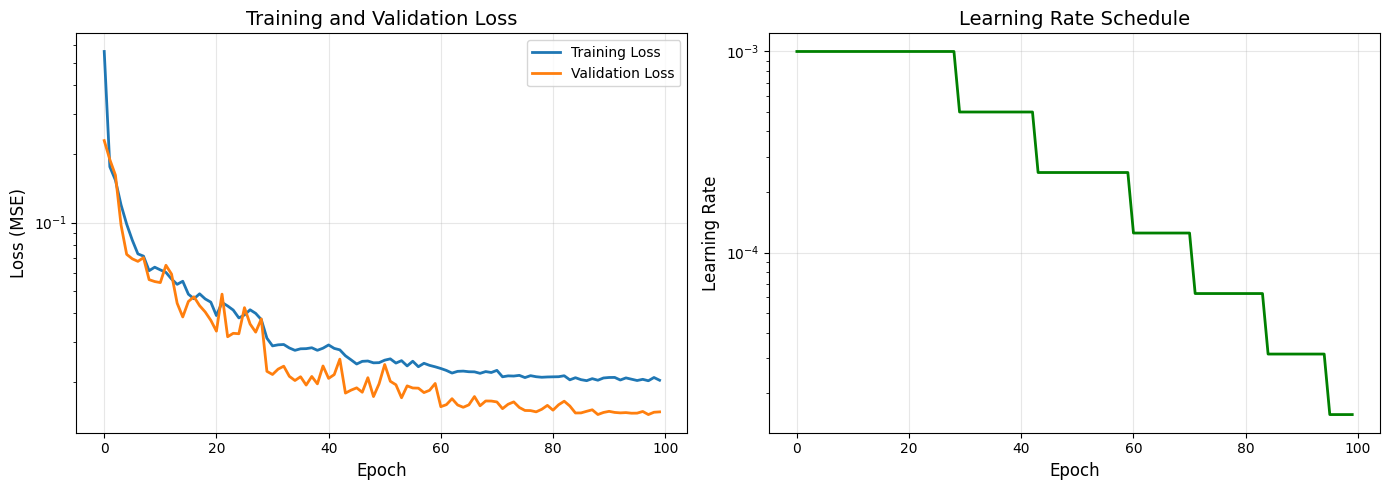

In [42]:
# Plot training history
plot_training_history(
    history,
    save_path=os.path.join(config.SAVE_DIR, 'training_history.png')
)

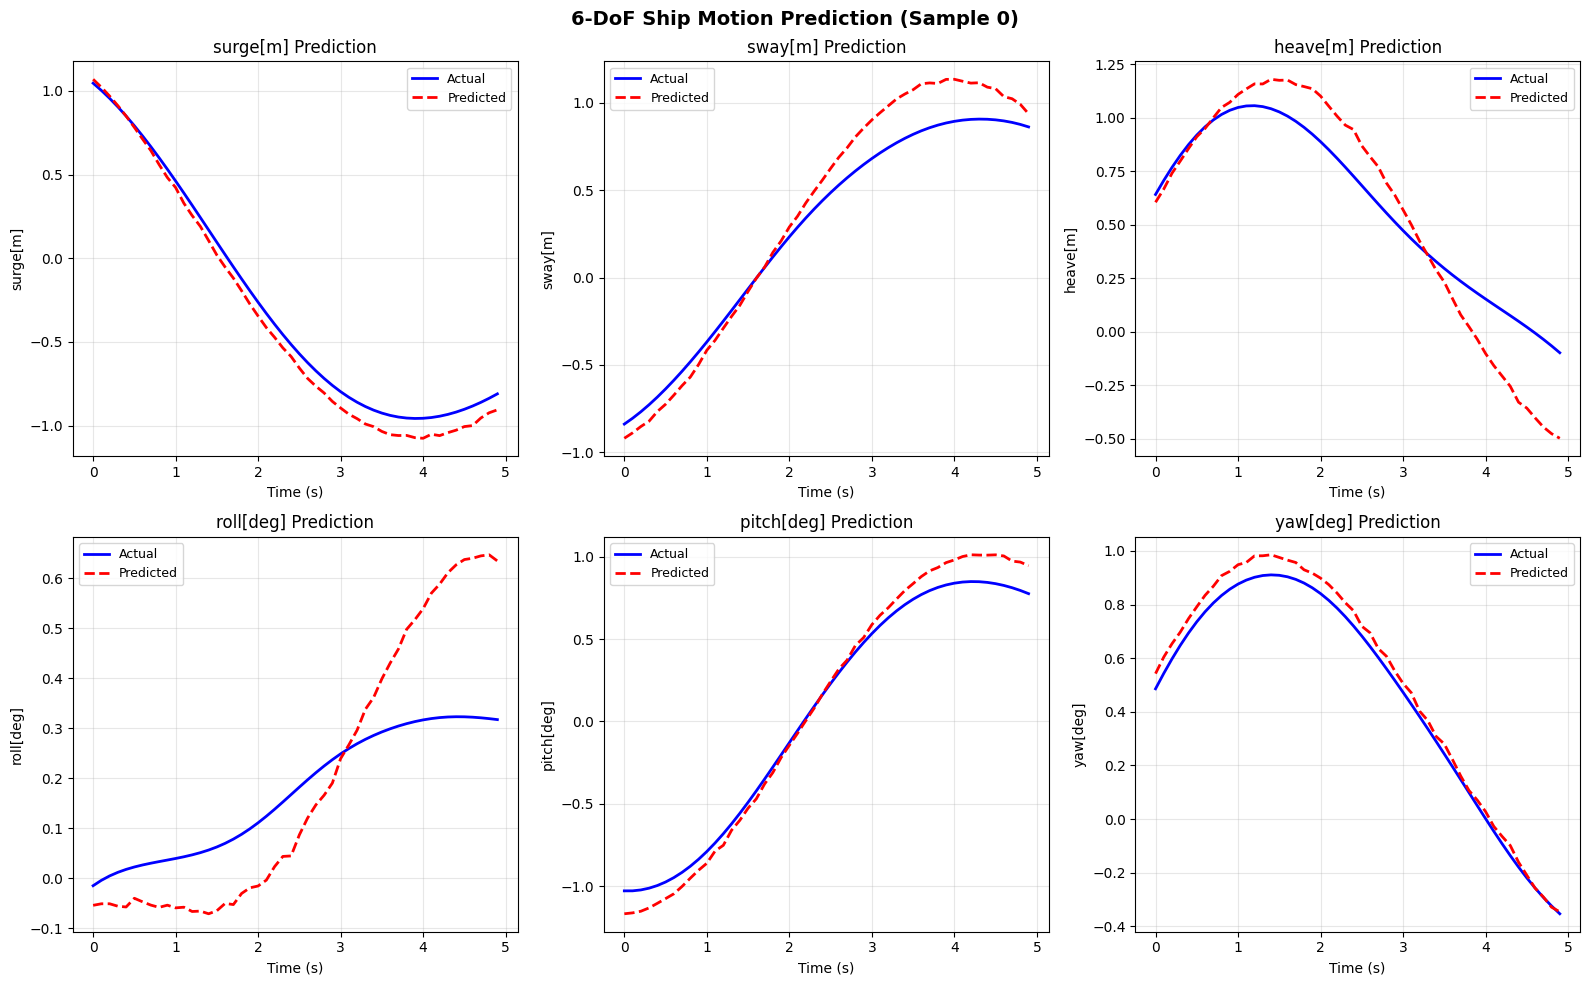

In [43]:
# Plot predictions for sample 0
plot_predictions(
    predictions, targets, config, sample_idx=0,
    save_path=os.path.join(config.SAVE_DIR, 'prediction_sample_0.png')
)

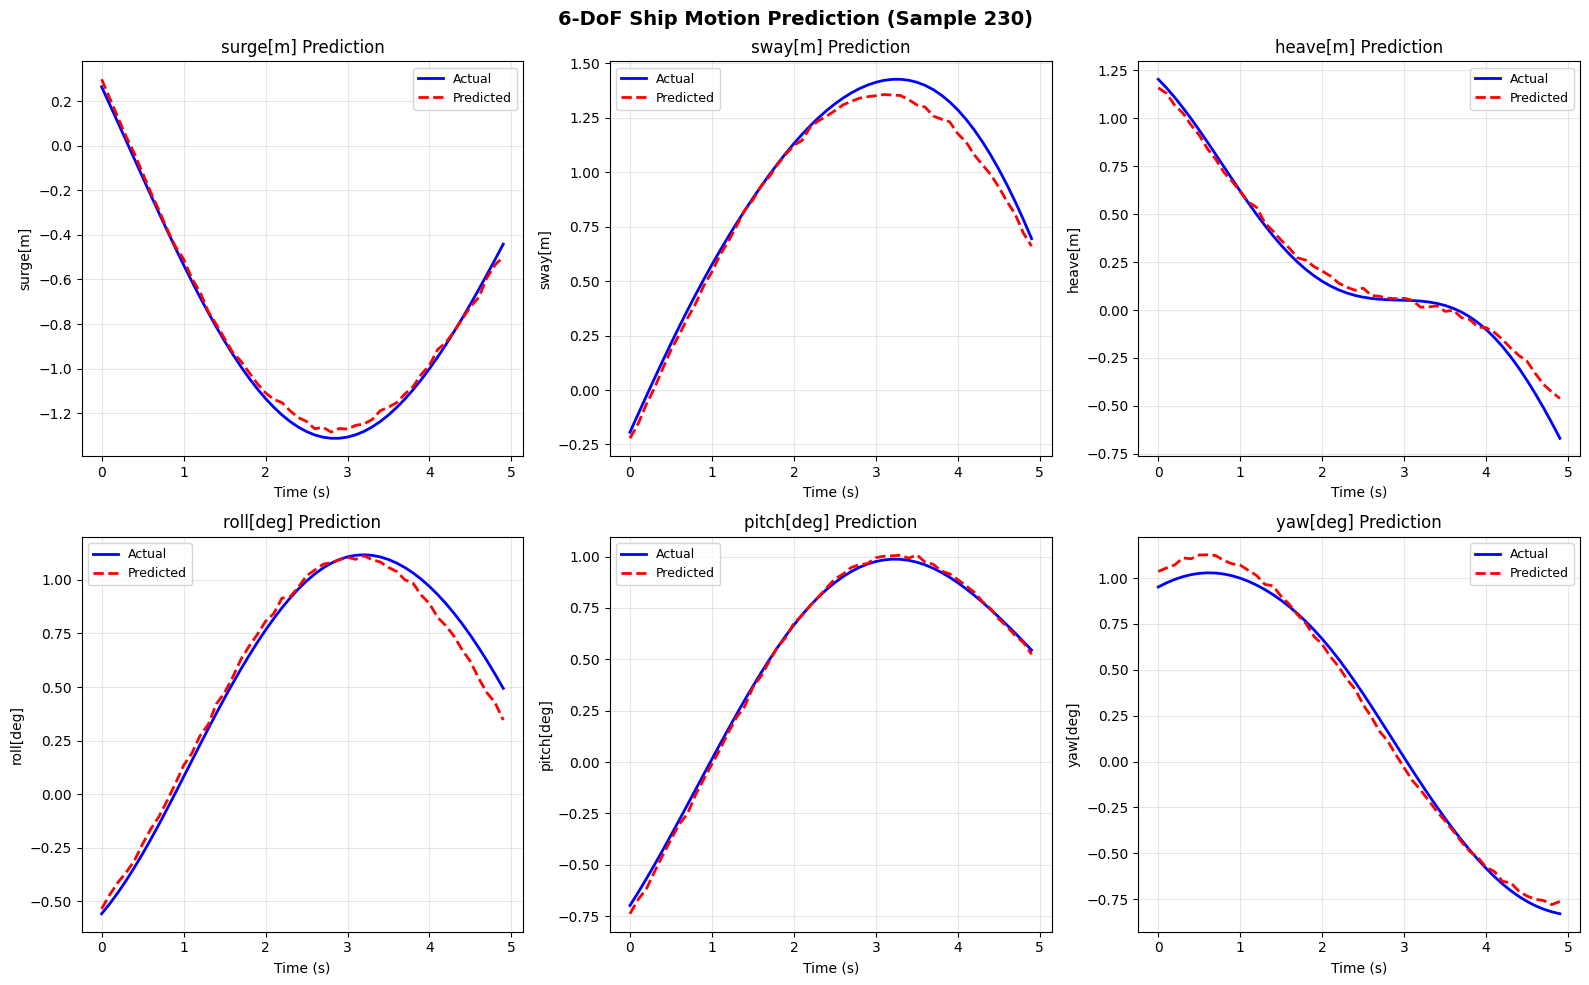

In [44]:
# Plot predictions for another sample
plot_predictions(
    predictions, targets, config, sample_idx=len(predictions)//2,
    save_path=os.path.join(config.SAVE_DIR, 'prediction_sample_mid.png')
)

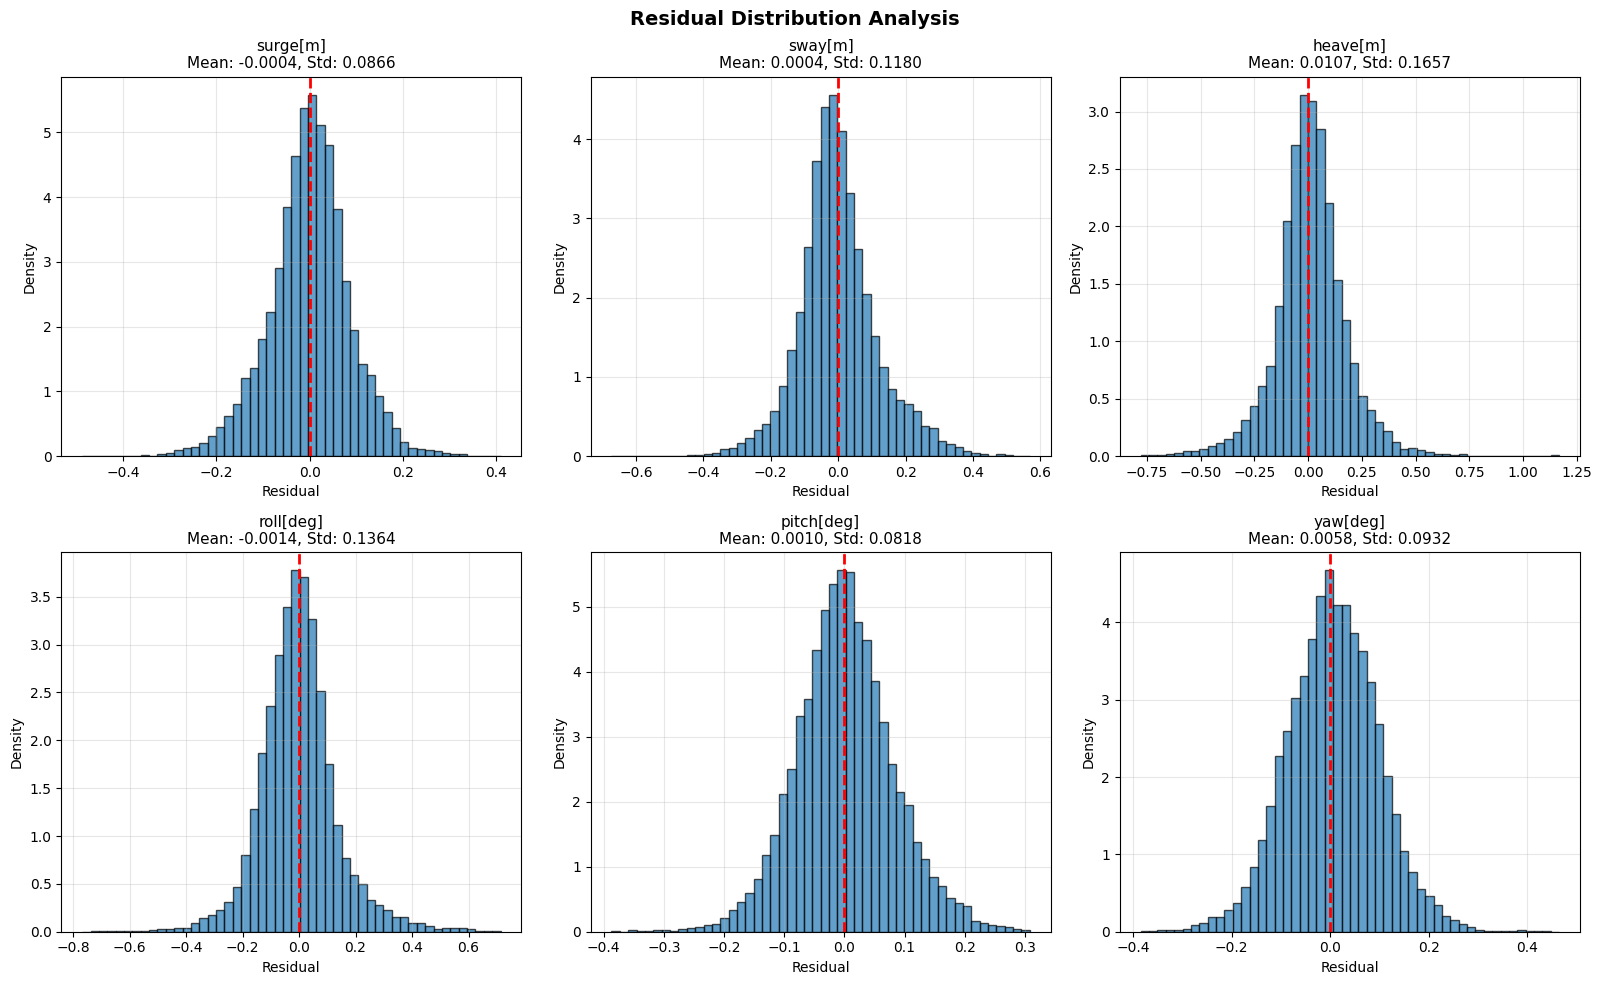

In [45]:
# Plot residual analysis
plot_residual_analysis(
    predictions, targets, config,
    save_path=os.path.join(config.SAVE_DIR, 'residual_analysis.png')
)

## 16. Save Model and Artifacts to Google Drive 💾

In [46]:
print("="*60)
print("💾 SAVING MODEL AND ARTIFACTS TO GOOGLE DRIVE")
print("="*60)

# Save final model checkpoint
trainer.save_checkpoint('final_model.pth')
print(f"✓ Final model saved to: {os.path.join(config.SAVE_DIR, 'final_model.pth')}")

# Save model for inference only (smaller file)
inference_model_path = os.path.join(config.SAVE_DIR, 'inference_model.pth')
torch.save(model.state_dict(), inference_model_path)
print(f"✓ Inference model saved to: {inference_model_path}")

# Save scaler
scaler_path = os.path.join(config.SAVE_DIR, 'scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(preprocessor.scaler, f)
print(f"✓ Scaler saved to: {scaler_path}")

# Save config
config_path = os.path.join(config.SAVE_DIR, 'config.json')
config_dict = {k: v for k, v in config.__dict__.items() if not k.startswith('_')}
with open(config_path, 'w') as f:
    json.dump(config_dict, f, indent=2)
print(f"✓ Config saved to: {config_path}")

# Save metrics
metrics_path = os.path.join(config.SAVE_DIR, 'metrics.json')
metrics_serializable = {
    'mse': float(metrics['mse']),
    'rmse': float(metrics['rmse']),
    'mae': float(metrics['mae']),
    'r2': float(metrics['r2']),
    'per_motion_rmse': {k: float(v) for k, v in metrics['per_motion_rmse'].items()}
}
with open(metrics_path, 'w') as f:
    json.dump(metrics_serializable, f, indent=2)
print(f"✓ Metrics saved to: {metrics_path}")

# Save training history
history_path = os.path.join(config.SAVE_DIR, 'training_history.json')
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)
print(f"✓ Training history saved to: {history_path}")

print("\n" + "="*60)
print("✅ ALL ARTIFACTS SAVED SUCCESSFULLY!")
print("="*60)

💾 SAVING MODEL AND ARTIFACTS TO GOOGLE DRIVE
✓ Final model saved to: /content/drive/MyDrive/ShipMotionTransformer/final_model.pth
✓ Inference model saved to: /content/drive/MyDrive/ShipMotionTransformer/inference_model.pth
✓ Scaler saved to: /content/drive/MyDrive/ShipMotionTransformer/scaler.pkl
✓ Config saved to: /content/drive/MyDrive/ShipMotionTransformer/config.json
✓ Metrics saved to: /content/drive/MyDrive/ShipMotionTransformer/metrics.json
✓ Training history saved to: /content/drive/MyDrive/ShipMotionTransformer/training_history.json

✅ ALL ARTIFACTS SAVED SUCCESSFULLY!


## 17. Model Summary Report

In [47]:
print("\n" + "="*70)
print("                    📋 MODEL TRAINING SUMMARY REPORT")
print("="*70)

print("\n--- DATA SUMMARY ---")
print(f"Total sequences created: {len(X_train) + len(X_val) + len(X_test)}")
print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")
print(f"Input window: {config.INPUT_WINDOW} timesteps ({config.INPUT_WINDOW/config.SAMPLING_RATE}s)")
print(f"Output window: {config.OUTPUT_WINDOW} timesteps ({config.OUTPUT_WINDOW/config.SAMPLING_RATE}s)")

print("\n--- MODEL ARCHITECTURE ---")
print(f"Model type: Transformer Encoder")
print(f"Embedding dimension (d_model): {config.D_MODEL}")
print(f"Number of attention heads: {config.NHEAD}")
print(f"Number of encoder layers: {config.NUM_ENCODER_LAYERS}")
print(f"Feedforward dimension: {config.DIM_FEEDFORWARD}")
print(f"Dropout rate: {config.DROPOUT}")
print(f"Total parameters: {total_params:,}")

print("\n--- TRAINING CONFIGURATION ---")
print(f"Batch size: {config.BATCH_SIZE}")
print(f"Initial learning rate: {config.LEARNING_RATE}")
print(f"Weight decay: {config.WEIGHT_DECAY}")
print(f"Epochs trained: {len(history['train_loss'])}")

print("\n--- FINAL METRICS ---")
print(f"Best validation loss: {trainer.best_val_loss:.6f}")
print(f"Test MSE: {metrics['mse']:.6f}")
print(f"Test RMSE: {metrics['rmse']:.6f}")
print(f"Test MAE: {metrics['mae']:.6f}")
print(f"Test R²: {metrics['r2']:.4f}")

print("\n--- PER-MOTION PERFORMANCE ---")
for motion, rmse in metrics['per_motion_rmse'].items():
    print(f"  {motion}: RMSE = {rmse:.6f}")

print("\n--- MODEL SAVED TO ---")
print(f"{config.SAVE_DIR}")

print("\n" + "="*70)
print("                         🎉 TRAINING COMPLETE!")
print("="*70)


                    📋 MODEL TRAINING SUMMARY REPORT

--- DATA SUMMARY ---
Total sequences created: 2299
Training samples: 1471
Validation samples: 368
Test samples: 460
Input window: 100 timesteps (10.0s)
Output window: 50 timesteps (5.0s)

--- MODEL ARCHITECTURE ---
Model type: Transformer Encoder
Embedding dimension (d_model): 128
Number of attention heads: 8
Number of encoder layers: 3
Feedforward dimension: 512
Dropout rate: 0.1
Total parameters: 700,460

--- TRAINING CONFIGURATION ---
Batch size: 32
Initial learning rate: 0.001
Weight decay: 1e-05
Epochs trained: 100

--- FINAL METRICS ---
Best validation loss: 0.014349
Test MSE: 0.013837
Test RMSE: 0.117631
Test MAE: 0.084684
Test R²: 0.9881

--- PER-MOTION PERFORMANCE ---
  surge[m]: RMSE = 0.086649
  sway[m]: RMSE = 0.117971
  heave[m]: RMSE = 0.166039
  roll[deg]: RMSE = 0.136429
  pitch[deg]: RMSE = 0.081792
  yaw[deg]: RMSE = 0.093412

--- MODEL SAVED TO ---
/content/drive/MyDrive/ShipMotionTransformer

                    

## 18. Inference Example
How to use the trained model for prediction on new data

In [48]:
def predict_future_motion(model, input_sequence, scaler, config, device):
    """
    Make predictions on new data.

    Args:
        model: Trained ShipMotionTransformer model
        input_sequence: numpy array of shape [INPUT_WINDOW, NUM_INPUT_FEATURES]
        scaler: Fitted StandardScaler (fitted on ALL_INPUT_FEATURES)
        config: Configuration object
        device: torch device

    Returns:
        Predicted motion array of shape [OUTPUT_WINDOW, NUM_OUTPUT_FEATURES]
    """
    model.eval()

    # Normalize input sequence (all input features)
    # Ensure the input_sequence has the correct number of features for the scaler
    if input_sequence.shape[1] != config.NUM_INPUT_FEATURES:
        raise ValueError(f"Input sequence must have {config.NUM_INPUT_FEATURES} features, but got {input_sequence.shape[1]}")

    input_normalized = scaler.transform(input_sequence)

    # Convert to tensor and add batch dimension
    input_tensor = torch.FloatTensor(input_normalized).unsqueeze(0).to(device)

    # Make prediction (output is NUM_OUTPUT_FEATURES = 6)
    with torch.no_grad():
        prediction_normalized = model(input_tensor)

    # Convert back to numpy and remove batch dimension
    prediction_normalized = prediction_normalized.cpu().numpy().squeeze(0) # Shape: [OUTPUT_WINDOW, NUM_OUTPUT_FEATURES]

    # Denormalize ONLY the predicted motion features.
    # The scaler was fitted on ALL_INPUT_FEATURES (7 features).
    # We need to use the mean and scale for just the motion columns.
    motion_means = scaler.mean_[config.MOTION_COL_INDICES_IN_INPUT]
    motion_scales = scaler.scale_[config.MOTION_COL_INDICES_IN_INPUT]

    prediction = (prediction_normalized * motion_scales) + motion_means

    return prediction

# Example usage
print("\n" + "="*60)
print("🔮 INFERENCE EXAMPLE")
print("="*60)

# X_test contains ALL_INPUT_FEATURES (e.g., 7 features, including ship speed)
# y_test contains MOTION_COLS (6 features)
sample_input = X_test[0] # This will have shape [INPUT_WINDOW, NUM_INPUT_FEATURES]
sample_target = y_test[0] # This will have shape [OUTPUT_WINDOW, NUM_OUTPUT_FEATURES]

# Ensure the model is loaded or available (it should be from previous cells)
# model = ShipMotionTransformer(config)
# trainer.load_checkpoint('best_model.pth') # if not already loaded

model.eval()
# Use the predict_future_motion function
prediction = predict_future_motion(model, sample_input, preprocessor.scaler, config, device)

print(f"Input shape (10s history): {sample_input.shape}")
print(f"Prediction shape (5s future): {prediction.shape}")
print(f"Target shape: {sample_target.shape}")

sample_rmse = np.sqrt(np.mean((prediction - sample_target) ** 2))
print(f"Sample RMSE: {sample_rmse:.6f}")


🔮 INFERENCE EXAMPLE
Input shape (10s history): (100, 7)
Prediction shape (5s future): (50, 6)
Target shape: (50, 6)
Sample RMSE: 0.469910


---

## 📁 Files Saved in Google Drive

The following files are saved in `/content/drive/MyDrive/ShipMotionTransformer/`:

| File | Description |
|------|-------------|
| `best_model.pth` | Best model checkpoint (lowest validation loss) |
| `final_model.pth` | Full training checkpoint with optimizer state |
| `inference_model.pth` | Model weights only (smaller, for deployment) |
| `scaler.pkl` | StandardScaler for data normalization |
| `config.json` | Model configuration parameters |
| `metrics.json` | Evaluation metrics |
| `training_history.json` | Loss curves data |
| `*.png` | Visualization plots |

---

## 📌 Notes

- **GPU Recommended**: Training is significantly faster with GPU acceleration
- **Early Stopping**: Training will stop if validation loss doesn't improve for 10 epochs
- **Model saves**: The best model is automatically saved during training
- **Reproducibility**: Random seeds are set for reproducible results